# Chargement du fichier CSV

Nous chargeons le dataset CSV dans Pandas.

In [93]:
import pandas as pd

# قراءة الملف مع تحديد الترميز المناسب للرموز الخاصة
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

# عرض أول بضعة أسطر للتأكد
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


# Informations sur les Données

Nous explorons la structure des données et les valeurs manquantes.

# Nettoyage des Données

Nous supprimons les valeurs manquantes et les transactions invalides.

In [94]:
# تنظيف البيانات بحذف السطور التي لا تحتوي على معرّف العميل
df = df.dropna(subset=['CustomerID'])

# الإبقاء فقط على المعاملات التي تكون فيها الكمية أكبر من صفر
df = df[df['Quantity'] > 0]

# طباعة الأبعاد للتأكد من نجاح العملية ولترى كم سطر بقي معك
print(df.shape)

(397924, 8)


# Création du Montant Total

Nous calculons le montant total des transactions.

In [95]:
df['MontantTotal'] = df['Quantity'] * df['UnitPrice']

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  MontantTotal  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom         15.30  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom         22.00  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  


# Création du Montant Total

Nous calculons le montant total des transactions.

In [96]:
df['MontantTotal'] = df['Quantity'] * df['UnitPrice']

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  MontantTotal  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom         15.30  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom         22.00  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom         20.34  


# Conversion des Dates

Nous convertissons la colonne InvoiceDate au format datetime.

In [97]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]


In [98]:
rfm['Recency'] = np.log1p(rfm['Recency'])

rfm['Frequency'] = np.log1p(rfm['Frequency'])

rfm['Monetary'] = np.log1p(rfm['Monetary'])

print(rfm.head())

             Recency  Frequency  Monetary  Cluster
CustomerID                                        
12346.0     1.915445   0.526589  2.505849        2
12347.0     0.741276   1.124748  2.237398        1
12348.0     1.673489   0.959135  2.139426        2
12349.0     1.385227   0.526589  2.136796        0
12350.0     1.908029   0.526589  1.919174        3


# Création de la Table RFM

Nous calculons les indicateurs RFM pour chaque client.

In [99]:
import pandas as pd

# 1. تأكد من تحويل التواريخ
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. حساب تاريخ المرجع
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 3. بناء جدول الـ rfm (تأكد من الحروف الصغيرة لاسم المتغير rfm)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'MontantTotal': 'sum'
})

# 4. تغيير أسماء الأعمدة مباشرة (تأكد من كتابتها rfm.columns بحروف صغيرة)
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 5. عرض النتيجة
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


# Visualisation des Données

Nous affichons la distribution de la variable Monetary.

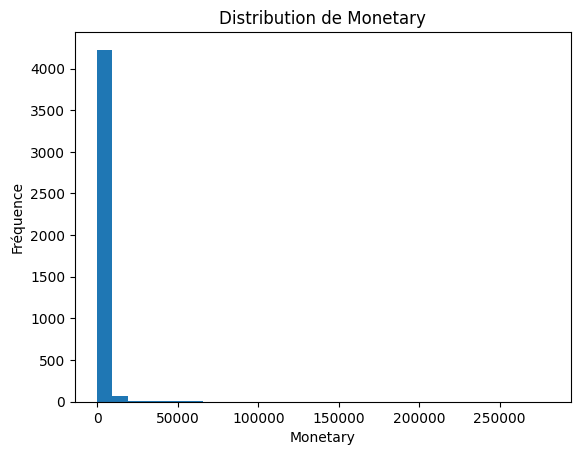

In [100]:
plt.hist(rfm['Monetary'], bins=30)

plt.title("Distribution de Monetary")

plt.xlabel("Monetary")

plt.ylabel("Fréquence")

plt.show()

In [101]:
rfm['Recency'] = np.log1p(rfm['Recency'])

rfm['Frequency'] = np.log1p(rfm['Frequency'])

rfm['Monetary'] = np.log1p(rfm['Monetary'])

print(rfm.head())

             Recency  Frequency   Monetary
CustomerID                                
12346.0     5.789960   0.693147  11.253955
12347.0     1.098612   2.079442   8.368925
12348.0     4.330733   1.609438   7.494564
12349.0     2.995732   0.693147   7.472245
12350.0     5.739793   0.693147   5.815324


# Standardisation des Données

Nous standardisons les variables avant K-Means.

# Transformation Logarithmique

Nous réduisons l'effet des valeurs extrêmes.

In [102]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# Méthode du Coude

Nous cherchons le nombre optimal de clusters.

In [103]:
inertias = []

for k in range(1,11):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(rfm_scaled)

    inertias.append(kmeans.inertia_)

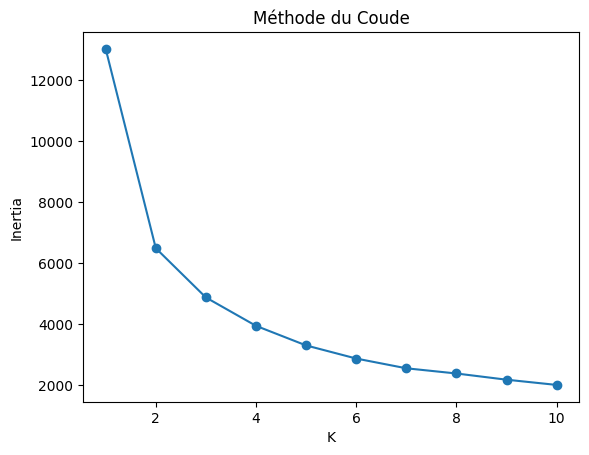

In [104]:
plt.plot(range(1,11), inertias, marker='o')

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Méthode du Coude")

plt.show()

# Application de K-Means

Nous appliquons le modèle K-Means avec K=4.

In [105]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = labels

print(rfm.head())

             Recency  Frequency   Monetary  Cluster
CustomerID                                         
12346.0     5.789960   0.693147  11.253955        2
12347.0     1.098612   2.079442   8.368925        1
12348.0     4.330733   1.609438   7.494564        2
12349.0     2.995732   0.693147   7.472245        0
12350.0     5.739793   0.693147   5.815324        3


# Analyse des Clusters

Nous analysons les différents groupes de clients.

In [106]:
print(rfm.groupby('Cluster').mean())

          Recency  Frequency  Monetary
Cluster                               
0        2.729648   1.074072  6.065420
1        2.158648   2.472246  8.347594
2        4.006628   1.564677  7.245714
3        5.037462   0.814577  5.588003


# Visualisation Finale

Nous affichons les clusters de clients.

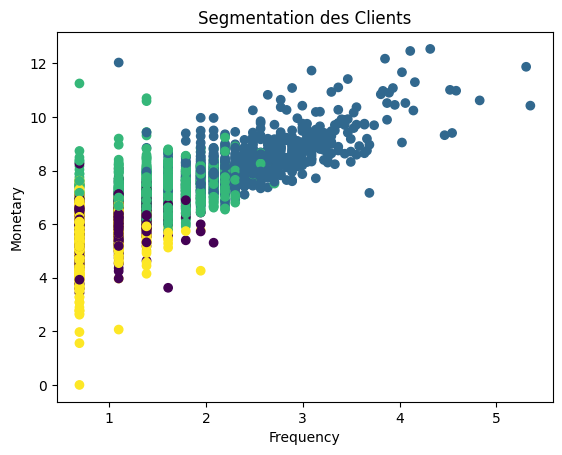

In [107]:
plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")

plt.ylabel("Monetary")

plt.title("Segmentation des Clients")

plt.show()